# Financial Data - Essential Workflows

# Executive Summary

- This notebook analyzes six major European companies across technology, industrials, luxury, healthcare and banking from 2025–2026.

- It builds a reusable financial-data workflow covering data acquisition, profiling, transformation, visualization and normalized performance comparison.

- The goal is to progress from raw market data toward investment visualization insights.


## Importing and Exporting Stock Price Data from Yahoo Finance

In [6]:
# Initializing the needed libraries
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [7]:
# I have selected 6 tickers (Companies that have rejecte me before)
ticker = [
    "ASML.AS",   # ASML – Netherlands – Semiconductors
    "SAP.DE",    # SAP – Germany – Software
    "SIE.DE",    # Siemens – Germany – Industrials
    "MC.PA",     # LVMH – France – Luxury
    "NVO",       # Novo Nordisk – Denmark – Healthcare (US ADR)
    "SAN.MC"     # Santander – Spain – Banking
]

In [8]:
# Downloading historical market data for the selected stock tickers from 1 Jan 2025 to 29 Jul 2026 using Yahoo Finance.
stocks = yf.download(ticker, start = "2025-01-01", end = "2026-07-29")

/tmp/ipykernel_542/2892074566.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download(ticker, start = "2025-01-01", end = "2026-07-29")
[*********************100%***********************]  6 of 6 completed


In [54]:
# Checking the first 5 rows of the dataset
stocks.head()

Price            Close                                               \
Ticker         ASML.AS       MC.PA        NVO    SAN.MC      SAP.DE   
Date                                                                  
2025-01-02  680.104858  610.562805  82.159119  4.222449  232.467712   
2025-01-03  678.133545  587.404785  82.281158  4.218134  228.862045   
2025-01-06  737.076050  609.794006  79.821640  4.363421  233.149857   
2025-01-07  727.810852  619.307068  78.235161  4.405617  237.096588   
2025-01-08  713.913025  610.851013  80.394279  4.382122  238.509613   

Price                         High                                   ...  \
Ticker          SIE.DE     ASML.AS       MC.PA        NVO    SAN.MC  ...   
Date                                                                 ...   
2025-01-02  180.949371  681.189059  614.406449  83.088483  4.302046  ...   
2025-01-03  178.710480  681.484810  610.947101  82.788083  4.238752  ...   
2025-01-06  184.738297  737.273194  618.730524  81.051396  4.363421  ...   
2025-01-07  185.178406  741.117253  620.940628  79.615120  4.417125  ...   
2025-01-08  187.187683  733.724813  619.787472  80.544482  4.468910  ...   

Price            Open                                       Volume            \
Ticker            NVO    SAN.MC      SAP.DE      SIE.DE    ASML.AS     MC.PA   
Date                                                                           
2025-01-02  82.525237  4.267522  230.275080  180.317897   446335.0  374039.0   
2025-01-03  82.130956  4.219573  230.957221  180.432717   442214.0  415336.0   
2025-01-06  80.835488  4.248342  229.154388  179.571586  1120484.0  611624.0   
2025-01-07  78.948610  4.342803  233.198576  185.063595   836999.0  432713.0   
2025-01-08  80.272245  4.408973  236.463151  184.872237   569713.0  380525.0   

Price                                                     
Ticker             NVO      SAN.MC     SAP.DE     SIE.DE  
Date                                                      
2025-01-02   4570300.0  26408337.0  1327871.0   970926.0  
2025-01-03   3769000.0  22705900.0   934542.0   723321.0  
2025-01-06  10695700.0  23517368.0  1532023.0  1183373.0  
2025-01-07   9567900.0  29366993.0  1698060.0  1224827.0  
2025-01-08   9196400.0  23072369.0  1333654.0  1267419.0  

[5 rows x 30 columns]

In [55]:
# Checking the last 5 rows of the dataset
stocks.tail()

Price             Close                                             \
Ticker          ASML.AS       MC.PA        NVO  SAN.MC      SAP.DE   
Date                                                                 
2026-07-22  1587.687988  474.000000  48.189999  12.078  132.039993   
2026-07-23  1577.300415  453.549988  48.180000  11.612  128.320007   
2026-07-24  1561.119995  461.700012  48.770000  11.980  140.199997   
2026-07-27  1429.800049  466.799988  49.669998  12.256  151.279999   
2026-07-28  1388.400024  470.299988  50.959999  12.240  159.240005   

Price                          High                                 ...  \
Ticker          SIE.DE      ASML.AS       MC.PA        NVO  SAN.MC  ...   
Date                                                                ...   
2026-07-22  271.250000  1587.687988  479.549988  49.540001  12.210  ...   
2026-07-23  268.200012  1601.870923  470.000000  48.930000  12.196  ...   
2026-07-24  272.250000  1592.482251  461.700012  49.520000  11.980  ...   
2026-07-27  272.750000  1592.000000  469.049988  49.959999  12.400  ...   
2026-07-28  271.750000  1426.000000  481.149994  51.230000  12.372  ...   

Price            Open                                     Volume            \
Ticker            NVO  SAN.MC      SAP.DE      SIE.DE    ASML.AS     MC.PA   
Date                                                                         
2026-07-22  49.450001  11.806  136.020004  267.549988   722150.0  570614.0   
2026-07-23  48.389999  12.082  131.000000  269.649994   601906.0  858456.0   
2026-07-24  48.830002  11.624  130.880005  267.149994   540900.0  602580.0   
2026-07-27  49.180000  12.160  142.380005  274.850006  1054840.0  613625.0   
2026-07-28  49.950001  12.292  152.199997  272.100006  1111714.0  876705.0   

Price                                                     
Ticker             NVO      SAN.MC     SAP.DE     SIE.DE  
Date                                                      
2026-07-22   8289400.0  57380602.0  3063860.0   826562.0  
2026-07-23   8178200.0  28698468.0  3338860.0   952254.0  
2026-07-24  10799100.0  18957635.0  4092805.0   700997.0  
2026-07-27   6803000.0  31446220.0  4522787.0  1037819.0  
2026-07-28   9521700.0  19456896.0  3621245.0   799262.0  

[5 rows x 30 columns]

In [56]:
# Performing data profiling
stocks.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 405 entries, 2025-01-02 to 2026-07-28
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, ASML.AS)   400 non-null    float64
 1   (Close, MC.PA)     400 non-null    float64
 2   (Close, NVO)       392 non-null    float64
 3   (Close, SAN.MC)    400 non-null    float64
 4   (Close, SAP.DE)    398 non-null    float64
 5   (Close, SIE.DE)    398 non-null    float64
 6   (High, ASML.AS)    400 non-null    float64
 7   (High, MC.PA)      400 non-null    float64
 8   (High, NVO)        392 non-null    float64
 9   (High, SAN.MC)     400 non-null    float64
 10  (High, SAP.DE)     398 non-null    float64
 11  (High, SIE.DE)     398 non-null    float64
 12  (Low, ASML.AS)     400 non-null    float64
 13  (Low, MC.PA)       400 non-null    float64
 14  (Low, NVO)         392 non-null    float64
 15  (Low, SAN.MC)      400 non-null    float64
 16  (Low, S

In [12]:
# Save the data to stocks csv for Power BI analysis
stocks.to_csv("stocks.csv")

In [13]:
stocks = pd.read_csv("stocks.csv", header = [0, 1], index_col = [0], parse_dates = [0])

In [14]:
stocks.head()

Price            Close                                               \
Ticker         ASML.AS       MC.PA        NVO    SAN.MC      SAP.DE   
Date                                                                  
2025-01-02  680.104858  610.562805  82.159119  4.222449  232.467712   
2025-01-03  678.133545  587.404785  82.281158  4.218134  228.862045   
2025-01-06  737.076050  609.794006  79.821640  4.363421  233.149857   
2025-01-07  727.810852  619.307068  78.235161  4.405617  237.096588   
2025-01-08  713.913025  610.851013  80.394279  4.382122  238.509613   

Price                         High                                   ...  \
Ticker          SIE.DE     ASML.AS       MC.PA        NVO    SAN.MC  ...   
Date                                                                 ...   
2025-01-02  180.949371  681.189059  614.406449  83.088483  4.302046  ...   
2025-01-03  178.710480  681.484810  610.947101  82.788083  4.238752  ...   
2025-01-06  184.738297  737.273194  618.730524  81.051396  4.363421  ...   
2025-01-07  185.178406  741.117253  620.940628  79.615120  4.417125  ...   
2025-01-08  187.187683  733.724813  619.787472  80.544482  4.468910  ...   

Price            Open                                       Volume            \
Ticker            NVO    SAN.MC      SAP.DE      SIE.DE    ASML.AS     MC.PA   
Date                                                                           
2025-01-02  82.525237  4.267522  230.275080  180.317897   446335.0  374039.0   
2025-01-03  82.130956  4.219573  230.957221  180.432717   442214.0  415336.0   
2025-01-06  80.835488  4.248342  229.154388  179.571586  1120484.0  611624.0   
2025-01-07  78.948610  4.342803  233.198576  185.063595   836999.0  432713.0   
2025-01-08  80.272245  4.408973  236.463151  184.872237   569713.0  380525.0   

Price                                                     
Ticker             NVO      SAN.MC     SAP.DE     SIE.DE  
Date                                                      
2025-01-02   4570300.0  26408337.0  1327871.0   970926.0  
2025-01-03   3769000.0  22705900.0   934542.0   723321.0  
2025-01-06  10695700.0  23517368.0  1532023.0  1183373.0  
2025-01-07   9567900.0  29366993.0  1698060.0  1224827.0  
2025-01-08   9196400.0  23072369.0  1333654.0  1267419.0  

[5 rows x 30 columns]

# Performing Column transformations

In [15]:
stocks.columns = stocks.columns.to_flat_index()

In [16]:
stocks.columns

Index([ ('Close', 'ASML.AS'),    ('Close', 'MC.PA'),      ('Close', 'NVO'),
         ('Close', 'SAN.MC'),   ('Close', 'SAP.DE'),   ('Close', 'SIE.DE'),
         ('High', 'ASML.AS'),     ('High', 'MC.PA'),       ('High', 'NVO'),
          ('High', 'SAN.MC'),    ('High', 'SAP.DE'),    ('High', 'SIE.DE'),
          ('Low', 'ASML.AS'),      ('Low', 'MC.PA'),        ('Low', 'NVO'),
           ('Low', 'SAN.MC'),     ('Low', 'SAP.DE'),     ('Low', 'SIE.DE'),
         ('Open', 'ASML.AS'),     ('Open', 'MC.PA'),       ('Open', 'NVO'),
          ('Open', 'SAN.MC'),    ('Open', 'SAP.DE'),    ('Open', 'SIE.DE'),
       ('Volume', 'ASML.AS'),   ('Volume', 'MC.PA'),     ('Volume', 'NVO'),
        ('Volume', 'SAN.MC'),  ('Volume', 'SAP.DE'),  ('Volume', 'SIE.DE')],
      dtype='object')

In [17]:
stocks.columns = pd.MultiIndex.from_tuples(stocks.columns)

In [18]:
stocks.head()

Close                                               \
               ASML.AS       MC.PA        NVO    SAN.MC      SAP.DE   
Date                                                                  
2025-01-02  680.104858  610.562805  82.159119  4.222449  232.467712   
2025-01-03  678.133545  587.404785  82.281158  4.218134  228.862045   
2025-01-06  737.076050  609.794006  79.821640  4.363421  233.149857   
2025-01-07  727.810852  619.307068  78.235161  4.405617  237.096588   
2025-01-08  713.913025  610.851013  80.394279  4.382122  238.509613   

                              High                                   ...  \
                SIE.DE     ASML.AS       MC.PA        NVO    SAN.MC  ...   
Date                                                                 ...   
2025-01-02  180.949371  681.189059  614.406449  83.088483  4.302046  ...   
2025-01-03  178.710480  681.484810  610.947101  82.788083  4.238752  ...   
2025-01-06  184.738297  737.273194  618.730524  81.051396  4.363421  ...   
2025-01-07  185.178406  741.117253  620.940628  79.615120  4.417125  ...   
2025-01-08  187.187683  733.724813  619.787472  80.544482  4.468910  ...   

                 Open                                       Volume            \
                  NVO    SAN.MC      SAP.DE      SIE.DE    ASML.AS     MC.PA   
Date                                                                           
2025-01-02  82.525237  4.267522  230.275080  180.317897   446335.0  374039.0   
2025-01-03  82.130956  4.219573  230.957221  180.432717   442214.0  415336.0   
2025-01-06  80.835488  4.248342  229.154388  179.571586  1120484.0  611624.0   
2025-01-07  78.948610  4.342803  233.198576  185.063595   836999.0  432713.0   
2025-01-08  80.272245  4.408973  236.463151  184.872237   569713.0  380525.0   

                                                          
                   NVO      SAN.MC     SAP.DE     SIE.DE  
Date                                                      
2025-01-02   4570300.0  26408337.0  1327871.0   970926.0  
2025-01-03   3769000.0  22705900.0   934542.0   723321.0  
2025-01-06  10695700.0  23517368.0  1532023.0  1183373.0  
2025-01-07   9567900.0  29366993.0  1698060.0  1224827.0  
2025-01-08   9196400.0  23072369.0  1333654.0  1267419.0  

[5 rows x 30 columns]

In [19]:
stocks.swaplevel(axis = 1).sort_index(axis = 1)

ASML.AS                                                    \
                  Close         High          Low         Open     Volume   
Date                                                                        
2025-01-02   680.104858   681.189059   661.081648   665.319970   446335.0   
2025-01-03   678.133545   681.484810   667.784123   680.104863   442214.0   
2025-01-06   737.076050   737.273194   691.538576   693.707038  1120484.0   
2025-01-07   727.810852   741.117253   719.925578   736.188956   836999.0   
2025-01-08   713.913025   733.724813   707.900527   728.303687   569713.0   
...                 ...          ...          ...          ...        ...   
2026-07-22  1587.687988  1587.687988  1535.750534  1556.126021   722150.0   
2026-07-23  1577.300415  1601.870923  1552.530319  1588.886560   601906.0   
2026-07-24  1561.119995  1592.482251  1540.344965  1558.123604   540900.0   
2026-07-27  1429.800049  1592.000000  1419.599976  1558.199951  1054840.0   
2026-07-28  1388.400024  1426.000000  1366.400024  1387.000000  1111714.0   

                 MC.PA                                                ...  \
                 Close        High         Low        Open    Volume  ...   
Date                                                                  ...   
2025-01-02  610.562805  614.406449  595.092105  612.965082  374039.0  ...   
2025-01-03  587.404785  610.947101  585.771225  610.178384  415336.0  ...   
2025-01-06  609.794006  618.730524  589.326617  590.671915  611624.0  ...   
2025-01-07  619.307068  620.940628  607.680070  611.427587  432713.0  ...   
2025-01-08  610.851013  619.787472  605.662071  618.538300  380525.0  ...   
...                ...         ...         ...         ...       ...  ...   
2026-07-22  474.000000  479.549988  470.850006  475.000000  570614.0  ...   
2026-07-23  453.549988  470.000000  453.200012  470.000000  858456.0  ...   
2026-07-24  461.700012  461.700012  449.500000  451.799988  602580.0  ...   
2026-07-27  466.799988  469.049988  462.600006  465.799988  613625.0  ...   
2026-07-28  470.299988  481.149994  451.799988  469.399994  876705.0  ...   

                SAP.DE                                                 \
                 Close        High         Low        Open     Volume   
Date                                                                    
2025-01-02  232.467712  232.857508  229.105680  230.275080  1327871.0   
2025-01-03  228.862045  231.590642  228.374794  230.957221   934542.0   
2025-01-06  233.149857  233.149857  228.374798  229.154388  1532023.0   
2025-01-07  237.096588  238.217261  233.149848  233.198576  1698060.0   
2025-01-08  238.509613  242.261456  236.463151  236.463151  1333654.0   
...                ...         ...         ...         ...        ...   
2026-07-22  132.039993  136.399994  132.039993  136.020004  3063860.0   
2026-07-23  128.320007  132.419998  127.500000  131.000000  3338860.0   
2026-07-24  140.199997  141.320007  130.860001  130.880005  4092805.0   
2026-07-27  151.279999  151.559998  142.000000  142.380005  4522787.0   
2026-07-28  159.240005  159.759995  151.000000  152.199997  3621245.0   

                SIE.DE                                                 
                 Close        High         Low        Open     Volume  
Date                                                                   
2025-01-02  180.949371  181.791357  178.691331  180.317897   970926.0  
2025-01-03  178.710480  180.872835  178.155536  180.432717   723321.0  
2025-01-06  184.738297  185.656813  179.188873  179.571586  1183373.0  
2025-01-07  185.178406  186.307433  184.106798  185.063595  1224827.0  
2025-01-08  187.187683  187.321634  184.661741  184.872237  1267419.0  
...                ...         ...         ...         ...        ...  
2026-07-22  271.250000  273.000000  267.500000  267.549988   826562.0  
2026-07-23  268.200012  271.100006  266.700012  269.649994   952254.0  
2026-07-24  272.250000  272.549988  267.149

## Initial Visualization


In [20]:
import pandas as pd

In [21]:
stocks = pd.read_csv("stocks.csv", header = [0,1], index_col= [0], parse_dates= [0])

### Statistical Analysis

In [25]:
stocks.describe()

Price         Close                                                  \
Ticker      ASML.AS       MC.PA         NVO      SAN.MC      SAP.DE   
count    400.000000  400.000000  392.000000  400.000000  398.000000   
mean     932.478756  530.213906   55.663638    8.401437  208.629718   
std      317.147713   72.360629   13.023092    2.119797   43.760854   
min      543.287292  426.845367   34.764999    4.218134  128.320007   
25%      660.617310  472.675011   45.952209    6.761070  164.252285   
50%      858.857727  497.164810   53.218231    8.445119  221.933311   
75%     1189.135498  597.222565   65.054440   10.207213  246.872532   
max     1719.329468  725.295532   85.379021   12.508000  273.153168   

Price                      High                                      ...  \
Ticker      SIE.DE      ASML.AS       MC.PA         NVO      SAN.MC  ...   
count   398.000000   400.000000  400.000000  392.000000  400.000000  ...   
mean    229.132072   947.059788  537.057218   56.414109    8.488135  ...   
std      24.163992   324.806327   72.291327   13.190509    2.140576  ...   
min     172.923706   556.029849  438.307922   35.199080    4.238752  ...   
25%     213.767872   666.736347  479.699997   46.915103    6.817644  ...   
50%     225.334465   871.597058  505.783698   53.560670    8.534857  ...   
75%     243.324997  1207.074190  603.709922   66.287083   10.329239  ...   
max     284.100006  1738.905868  732.886762   88.054455   12.594000  ...   

Price         Open                                            Volume  \
Ticker         NVO      SAN.MC      SAP.DE      SIE.DE       ASML.AS   
count   392.000000  400.000000  398.000000  398.000000  4.000000e+02   
mean     55.743460    8.381758  208.775438  229.122090  7.229860e+05   
std      13.132756    2.122136   43.667737   24.101064  3.311966e+05   
min      35.006157    4.219573  130.880005  163.582293  5.958500e+04   
25%      46.203011    6.730345  164.353463  213.988186  5.361465e+05   
50%      52.967428    8.416344  221.810394  226.117808  6.599560e+05   
75%      65.647986   10.201592  247.700390  242.625747  8.277748e+05   
max      86.627556   12.550000  276.027996  283.100006  2.712660e+06   

Price                                                                         
Ticker         MC.PA           NVO        SAN.MC        SAP.DE        SIE.DE  
count   4.000000e+02  3.920000e+02  4.000000e+02  3.980000e+02  3.980000e+02  
mean    5.323002e+05  1.510096e+07  2.919895e+07  2.123004e+06  1.218796e+06  
std     2.521602e+05  1.176297e+07  1.593831e+07  1.430647e+06  6.073698e+05  
min     5.587800e+04  3.769000e+06  5.100182e+06  4.738520e+05  4.248390e+05  
25%     3.810528e+05  8.832300e+06  1.950005e+07  1.258516e+06  8.508518e+05  
50%     4.843770e+05  1.190385e+07  2.389889e+07  1.677350e+06  1.044798e+06  
75%     5.950508e+05  1.699978e+07  3.318141e+07  2.550350e+06  1.402304e+06  
max     2.474373e+06  1.107356e+08  1.201292e+08  1.584679e+07  5.246090e+06  

[8 rows x 30 columns]

In [26]:
# Create the dataframe based on the close price and get all the rows
close = stocks.loc[:, "Close"].copy()

In [27]:
# Inspect the dataframe
close.head()

Ticker,ASML.AS,MC.PA,NVO,SAN.MC,SAP.DE,SIE.DE
Date,,,,,,
2025-01-02,680.104858,610.562805,82.159119,4.222449,232.467712,180.949371
2025-01-03,678.133545,587.404785,82.281158,4.218134,228.862045,178.710480
2025-01-06,737.076050,609.794006,79.821640,4.363421,233.149857,184.738297
2025-01-07,727.810852,619.307068,78.235161,4.405617,237.096588,185.178406
2025-01-08,713.913025,610.851013,80.394279,4.382122,238.509613,187.187683


In [28]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

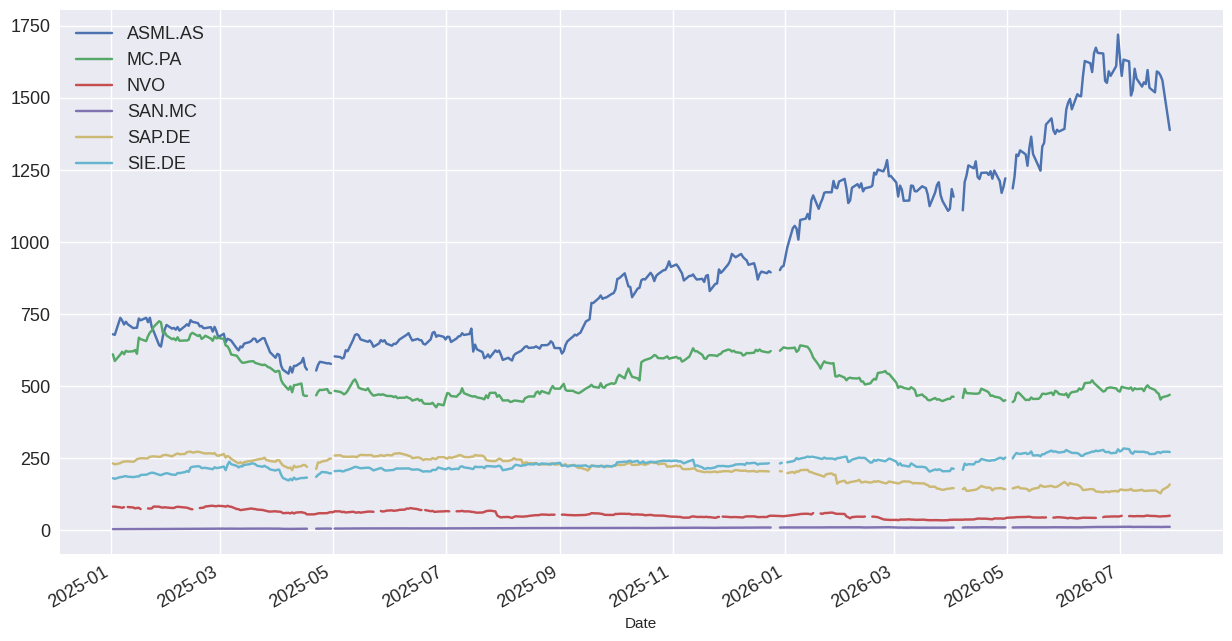

In [29]:
close.plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

- It is hard to understand if the stock is performing well from the chart since all stocks have different starting points.

- Next I would perform Normalization in order to deep dive in stock performance from the price of 100

## Normalizing Time Series to a Base Value (100)

In [30]:
close.head()

Ticker,ASML.AS,MC.PA,NVO,SAN.MC,SAP.DE,SIE.DE
Date,,,,,,
2025-01-02,680.104858,610.562805,82.159119,4.222449,232.467712,180.949371
2025-01-03,678.133545,587.404785,82.281158,4.218134,228.862045,178.710480
2025-01-06,737.076050,609.794006,79.821640,4.363421,233.149857,184.738297
2025-01-07,727.810852,619.307068,78.235161,4.405617,237.096588,185.178406
2025-01-08,713.913025,610.851013,80.394279,4.382122,238.509613,187.187683


In [31]:
close.iloc[0,0]

np.float64(680.1048583984375)

In [33]:
# Performing normalization
norm = close.div(close.iloc[0]).mul(100)
norm

Ticker,ASML.AS,MC.PA,NVO,SAN.MC,SAP.DE,SIE.DE
Date,,,,,,
2025-01-02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2025-01-03,99.710146,96.207103,100.148541,99.897799,98.448960,98.762697
2025-01-06,108.376825,99.874084,97.154937,103.338634,100.293436,102.093915
2025-01-07,107.014506,101.432164,95.223953,104.337943,101.991191,102.337137
2025-01-08,104.971023,100.047204,97.851925,103.781508,102.599028,103.447545
...,...,...,...,...,...,...
2026-07-22,233.447529,77.633291,58.654474,286.042512,56.799283,149.903809
2026-07-23,231.920180,74.283920,58.642304,275.006273,55.199067,148.218261
2026-07-24,229.541074,75.618758,59.360423,283.721572,60.309449,150.456450


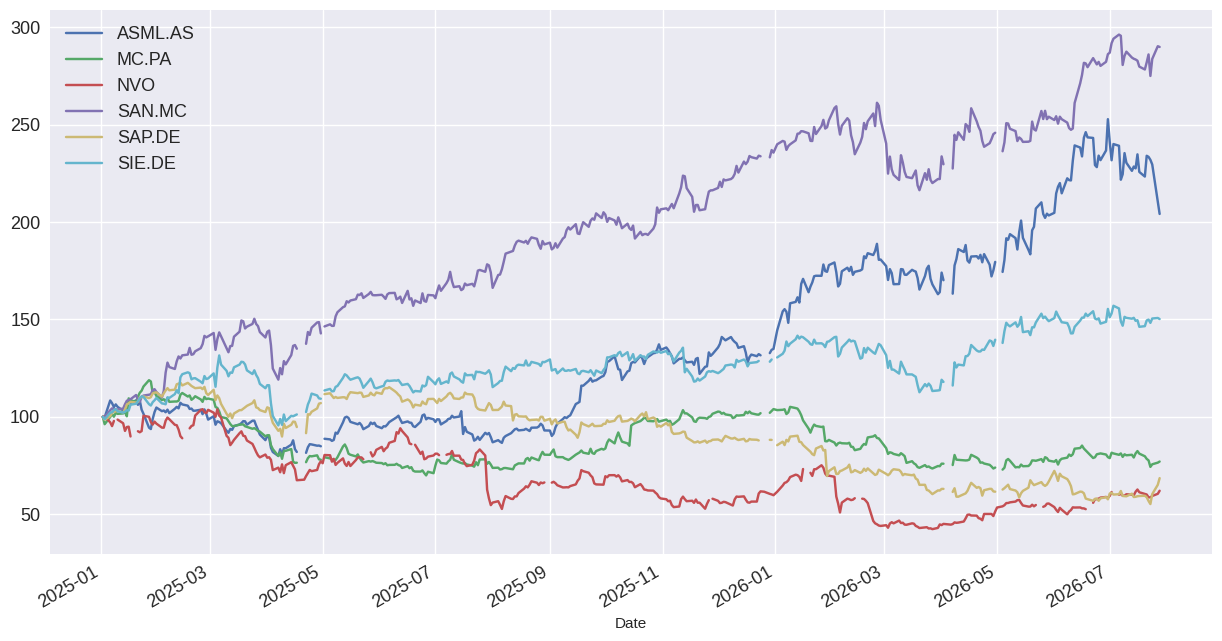

In [34]:
norm.plot(figsize = (15, 8 ), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

# Summary

- The normalized chart shows a clear divergence in performance across the six European equities since January 2025.

- Santander (SAN.MC) is the strongest performer, rising from a base of 100 to roughly 290, followed by ASML at approximately 200, although ASML displays considerably greater volatility and a sharp late-period correction.

- Siemens (SIE.DE) shows a comparatively stable upward trajectory, reaching around 150, suggesting attractive growth with visibly lower price fluctuations than ASML.

- In contrast, LVMH (MC.PA), Novo Nordisk (NVO), and SAP (SAP.DE) finish below their initial normalized values.

- Novo Nordisk shows the weakest overall performance, experiencing substantial drawdowns and ending near 60.

- LVMH also remains materially below its starting level, while SAP moves from early gains into a prolonged decline.

# Future Improvement

- From a portfolio-strategy perspective, the chart demonstrates why price performance alone is insufficient for investment selection.

- Santander generated exceptional returns, but the chart does not establish whether those returns were efficient relative to risk. Similarly, Siemens' lower absolute return may prove attractive after adjusting for volatility.

- The next analysis should therefore calculate daily returns, annualized volatility, Sharpe ratios, drawdowns and correlations to determine whether the apparent winners also delivered superior risk-adjusted performance and whether combining these securities provides meaningful diversification.